# Introdução
Busca-se, nesta etapa do projeto, implementar o mecanismo de inferência da espécie à qual uma folha pertence. Para tal, utilizou-se uma rede neural probabilística, dada a sua simplicidade de implementação e rápido treinamento.

A implementação da rede utilizou, massivamente, dos métodos disponibilizados na biblioteca Numpy, pois as implementações são majoritariamente feitas em C, que possui laços mais otimizados.

Por fim, analisaram-se os resultados das inferências feitas com um pequeno número de dados para treinamento.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import os

/home/viktor/.venv/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


# Implementação
## Função Radial Basis

Em jargão matemático, uma função de base radial é uma função cujo resultado da evaluação por `x` depende apenas da distância (Euclidiana, por exemplo) de `x` e um ponto fixo `c`, onde este pode ser a origem. 

Assim como no artigo, a função de distância a ser usada será a $radbas(n) = e^{-n^2}$. Esta função pode ser implementada utilizando puramente os métodos do Numpy, o que diminui consideravelmente o seu tempo de execução.

In [2]:
def radbas(n):
    return np.exp(-np.square(n))

Acerca da camada competitiva, similar ao caso outrora discutido, esta foi implementada de forma direta, utilizando também métodos disponibilizados pelo NumPy.

In [3]:
def competitive_layer(d):
    c = np.zeros_like(d)
    c[np.argmax(d)][0] = 1
    return c

## Mapeamento Espécie para Arquivo

O dataset Flavia, utilizado para o projeto, organiza as imagens das folhas em faixas contíguas de índices de arquivo, onde cada faixa corresponde a uma espécie distinta. Abaixo, construiu-se o dicionário `PLANT_TYPES` (índice $\to$ nome científico) e a lista `PLANT_RANGES` (intervalo de arquivos $\to$ índice da espécie), possibilitando recuperar o rótulo de qualquer imagem a partir do seu nome de arquivo.

In [4]:


PLANT_TYPES = {
    1: "Phyllostachys edulis (pubescent bamboo)",
    2: "Aesculus chinensis (Chinese horse chestnut)",
    3: "Berberis anhweiensis (Anhui Barberry)",
    4: "Cercis chinensis (Chinese redbud)",
    5: "Indigofera tinctoria (true indigo)",
    6: "Acer palmatum (Japanese maple)",
    7: "Phoebe nanmu (Nanmu)",
    8: "Kalopanax septemlobus (castor aralia)",
    9: "Cinnamomum japonicum (Chinese cinnamon)",
    10: "Koelreuteria paniculata (goldenrain tree)",
    11: "Ilex macrocarpa (Big-fruited Holly)",
    12: "Pittosporum tobira (Japanese cheesewood)",
    14: "Chimonanthus praecox (wintersweet)",
    15: "Cinnamomum camphora (camphortree)",
    16: "Viburnum awabuki (Japan Arrowwood)",
    17: "Osmanthus fragrans (sweet osmanthus)",
    18: "Cedrus deodara (deodar)",
    19: "Ginkgo biloba (ginkgo)",
    20: "Lagerstroemia indica (crape myrtle)",
    21: "Nerium oleander (oleander)",
    22: "Podocarpus macrophyllus (yew plum pine)",
    23: "Prunus serrulata (Japanese Flowering Cherry)",
    24: "Ligustrum lucidum (Glossy Privet)",
    25: "Toona sinensis (Chinese Toon)",  # Corrigido: Toona, não Tonna
    26: "Prunus persica (peach)",
    27: "Manglietia fordiana (Ford Woodlotus)",
    28: "Acer buergerianum (trident maple)",
    29: "Mahonia bealei (Beale's barberry)",
    30: "Magnolia grandiflora (southern magnolia)",
    31: "Populus ×canadensis (Canadian poplar)",
    32: "Liriodendron chinense (Chinese tulip tree)",
    33: "Citrus reticulata (tangerine)",
}


def get_plant_type(label: int) -> str:
    return PLANT_TYPES.get(label, "Unknown plant")

PLANT_RANGES = [
    (1001, 1059, 1),
    (1060, 1122, 2),
    (1123, 1194, 4),
    (1195, 1267, 5),
    (1268, 1323, 6),
    (1324, 1385, 7),
    (1386, 1437, 8),
    (1438, 1496, 10),
    (1497, 1551, 9),
    (1552, 1616, 3),
    (2001, 2050, 11),
    (2051, 2113, 12),
    (2114, 2165, 14),
    (2166, 2230, 15),
    (2231, 2290, 16),
    (2291, 2346, 17),
    (2347, 2423, 18),
    (2424, 2485, 19),
    (2486, 2546, 20),
    (2547, 2612, 21),
    (2616, 2675, 22),
    (3001, 3055, 23),
    (3056, 3110, 24),
    (3111, 3175, 25),
    (3176, 3229, 26),
    (3230, 3281, 27),
    (3282, 3334, 28),
    (3335, 3389, 29),
    (3390, 3446, 30),
    (3447, 3510, 31),
    (3511, 3563, 32),
    (3566, 3621, 33),
]

def file_index_to_plant_label(file_index: int) -> int:
    for start, end, label in PLANT_RANGES:
        if start <= file_index <= end:
            return label
    raise ValueError(f"File index {file_index} not found.")

In [5]:
# leaf features
R = 5 # número de features
Q_train = 1800 # número de amostras para o treinamento
K = 32 # número de espécies

## Carregamento das Features

As features de entrada (W) foram geradas em uma etapa anterior do projeto, e estão salvas em `leaf_features_pca.npy`. A matriz tem shape $(1907, 5)$, ou seja, 1907 amostras (o total de imagens do dataset) por 5 componentes principais ($R$), já na convenção $Q \times R$ usada no artigo — não é necessário transpor.

In [6]:
W = np.load("./leaf_features_pca.npy")

## Alinhamento entre Features e Rótulos

Como `leaf_features_pca.npy` não guarda os rótulos das espécies, é necessário reconstruí-los a partir do nome dos arquivos de imagem, **na mesma ordem** em que eles foram percorridos durante a extração das features (feita com `sorted(os.listdir(...))` no notebook de extração).

In [7]:
IMG_DIR = "./Leaves"  # caminho real das imagens :D


def extract_file_index(filename: str) -> int:
    # assume nomes tipo "1001.jpg"
    name, _ = os.path.splitext(filename)
    return int(name)


# lista os arquivos *NA MESMA ORDEM* usada para gerar
# leaf_features_pca.npy (MUITO IMPORTANTE)
filenames = sorted(os.listdir(IMG_DIR), key=extract_file_index)
file_indices = [extract_file_index(f) for f in filenames]
labels = np.array([file_index_to_plant_label(idx) for idx in file_indices])

if len(labels) != W.shape[0]:
    print ("Número de rótulos não bate com número de linhas de W!")

# Treinamento

## Separação em Treino e Teste

Seguindo o protocolo descrito no artigo, separaram-se 10 folhas de cada espécie para o conjunto de teste, usando o restante para treino. Diferente do artigo original, o dataset disponibilizado possui apenas 1907 imagens no total, resultando em 1587 amostras de treino e 320 de test* (32 espécies × 10).

In [8]:
def split_train_test(W, labels, n_test_per_class=10, seed=0):
    rng = np.random.default_rng(seed)
    train_idx, test_idx = [], []
    for label in np.unique(labels):
        idx_species = np.where(labels == label)[0]
        rng.shuffle(idx_species)
        test_idx.extend(idx_species[:n_test_per_class])
        train_idx.extend(idx_species[n_test_per_class:])
    return np.array(train_idx), np.array(test_idx)


train_idx, test_idx = split_train_test(W, labels)

W_train, y_train = W[train_idx], labels[train_idx]
W_test, y_test = W[test_idx], labels[test_idx]

Q_train = W_train.shape[0]
print("Amostras de treino:", Q_train)
print("Amostras de teste:", len(test_idx))

Amostras de treino: 1587
Amostras de teste: 320


## Bias da Camada Radial Basis

O artigo define o bias como $b = \sqrt{\ln(0.5)}/s$. Como $\ln(0.5) < 0$, essa expressão não é bem definida sobre os reai, sendo, possivelmente, um erro. Usa-se, portanto, $b = \sqrt{-\ln(0.5)}/s$, garantindo que os neurônios da camada radial basis respondam com 0.5 para entradas a uma distância $s$ do seu vetor de peso, como descrito no texto.

In [9]:
# como dito no paper, o valor de s será definido como 1/32
s = 1 / 32

# acredito haver um sinal de menos no ln pois ln(0.5) é um valor negativo
b = np.sqrt(-np.log(0.5 * np.ones((Q_train, 1)))) / s

## Pesos da Camada Competitiva

A matriz `M` (dimensão $K \times Q_{train}$) codifica, em formato one-hot, a espécie de cada amostra de treino: a coluna $i$ tem um único valor 1, na linha correspondente à espécie da $i$-ésima amostra de treino. Diferente de uma rede treinada por otimização, aqui os "pesos" não são ajustados iterativamente — são simplesmente atribuídos a partir dos rótulos conhecidos.

In [10]:
species_list = sorted(np.unique(labels))  # os 32 rótulos únicos
species_to_row = {label: i for i, label in enumerate(species_list)}
K = len(species_list)


def build_M(y_train, species_to_row, K, Q_train):
    M = np.zeros((K, Q_train))
    for col, label in enumerate(y_train):
        row = species_to_row[label]
        M[row, col] = 1
    return M


M = build_M(y_train, species_to_row, K, Q_train)

## Inferência

A função `classify` implementa o fluxo completo da rede descrito na Figura 5 do artigo: calcula a distância euclidiana entre a amostra de entrada `p` e cada vetor de peso em `W_train` (camada radial basis), pondera essas distâncias pelo bias `b` e aplica a função `radbas`, produzindo o vetor de ativação `a`. Em seguida, `a` é multiplicado pela matriz `M`, e a espécie prevista é a que corresponde ao maior valor resultante.

In [11]:
def classify(p, W_train, b, M):
    v = np.linalg.norm(W_train - p.T, axis=1).reshape((-1, 1))
    n = v * b
    a = radbas(n)
    d = M @ a
    c = competitive_layer(d)
    predicted_row = np.argmax(c)
    return predicted_row

## Avaliação no Conjunto de Teste

Aplica-se, a seguir, a função `classify` a cada uma das 320 amostras de teste (10 por espécie, nunca vistas durante a construção de `M`), comparando a espécie prevista com o rótulo real de cada folha.

In [12]:
row_to_species = {row: label for label, row in species_to_row.items()}

y_pred = []
for i in range(W_test.shape[0]):
    p_test = W_test[i].reshape((R, 1))
    pred_row = classify(p_test, W_train, b, M)
    y_pred.append(row_to_species[pred_row])

y_pred = np.array(y_pred)

# Discussão dos Resultados

Obteve-se uma acurácia geral de 75,62%, abaixo dos 90,3% reportados no artigo original. Um padrão, no entanto, é que as espécies com maior taxa de erro nos experimentos, *Cinnamomum japonicum* e *Cinnamomum camphora* (6 erros em 10 cada), são exatamente as duas espécies com maior número de reconhecimentos incorretos no artigo, o que é esperado dado que pertencem ao mesmo gênero e possuem folhas visualmente muito similares. Essa coincidência sugere que as features estão capturando discriminação real entre espécies, e que a diferença de acurácia é proporcional, não aleatório.

Uma possível explicação para essa diferença pode ser dada principalmente por duas limitações da reprodução:

1. **Extração de features sem intervenção manual.** O artigo original depende de marcação manual dos dois terminais da nervura principal da folha para calcular o comprimento e a largura fisiológicos ($L_p$, $W_p$). Nesta implementação, todavia, essa marcação foi automatizada, podendo introduz, na duas features e nas quatro features derivadas delas, ruído.

2. **Tamanho do dataset.** Usaram-se 1907 imagens do dataset Flavia público, contra as 2120 usadas no artigo, resultando em menos amostras de treino por espécie (1587 vs. 1800).

In [13]:
accuracy = np.mean(y_pred == y_test)
print(f"Acurácia geral: {accuracy*100:.2f}%")

print(f"{'Espécie':40s} {'Erros':>6s} / {'Total':>6s}")
for label in species_list:
    mask = y_test == label
    total = mask.sum()
    erros = np.sum(y_pred[mask] != label)
    print(f"{get_plant_type(label):40s} {erros:6d} de {total:4d}")

Acurácia geral: 75.62%
Espécie                                   Erros /  Total
Phyllostachys edulis (pubescent bamboo)       2 de   10
Aesculus chinensis (Chinese horse chestnut)      4 de   10
Berberis anhweiensis (Anhui Barberry)         3 de   10
Cercis chinensis (Chinese redbud)             0 de   10
Indigofera tinctoria (true indigo)            0 de   10
Acer palmatum (Japanese maple)                2 de   10
Phoebe nanmu (Nanmu)                          4 de   10
Kalopanax septemlobus (castor aralia)         0 de   10
Cinnamomum japonicum (Chinese cinnamon)       6 de   10
Koelreuteria paniculata (goldenrain tree)      1 de   10
Ilex macrocarpa (Big-fruited Holly)           3 de   10
Pittosporum tobira (Japanese cheesewood)      2 de   10
Chimonanthus praecox (wintersweet)            4 de   10
Cinnamomum camphora (camphortree)             6 de   10
Viburnum awabuki (Japan Arrowwood)            3 de   10
Osmanthus fragrans (sweet osmanthus)          2 de   10
Cedrus deodara (deod

## Erros por Espécie

Visualiza-se, abaixo, o número de erros de classificação por espécie no conjunto de teste (10 folhas por espécie), ordenado da maior para a menor taxa de erro.

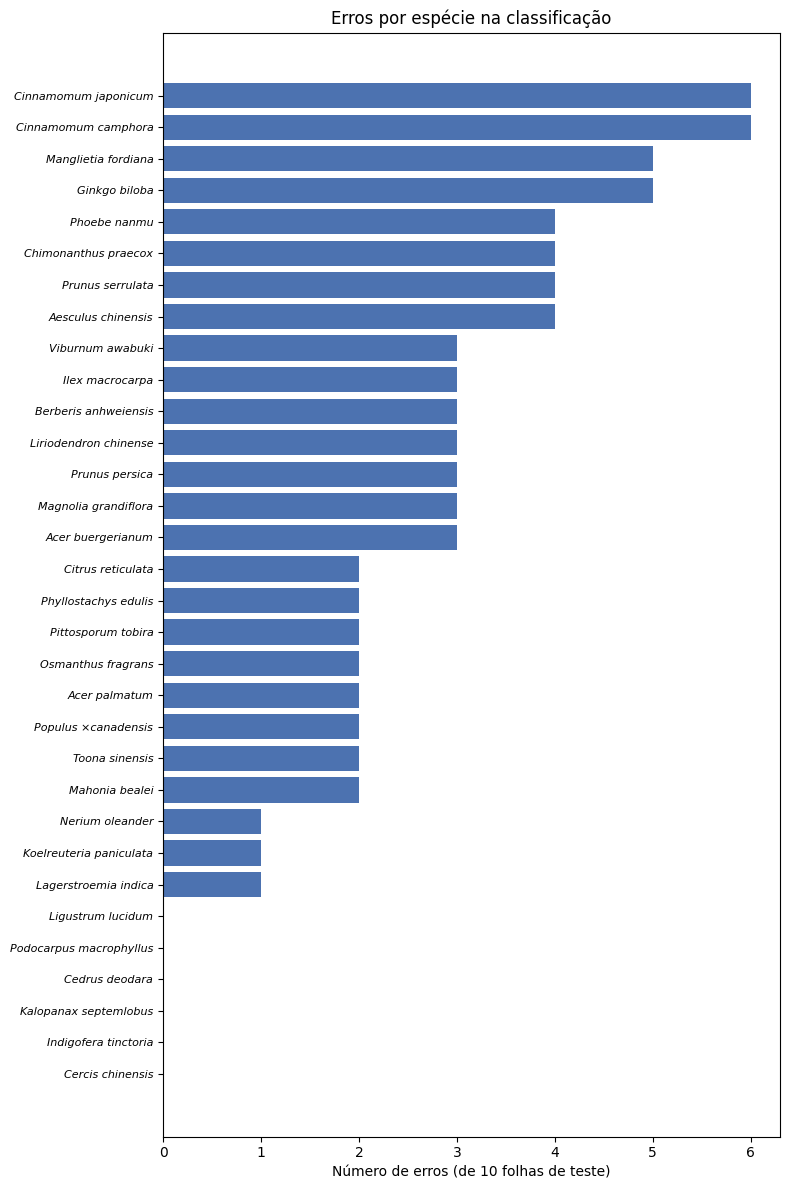

In [14]:
nossos_erros = []
nomes = []

for label in species_list:
    mask = y_test == label
    erros = np.sum(y_pred[mask] != label)
    nossos_erros.append(erros)
    nomes.append(get_plant_type(label).split(" (")[0])  # só o nome científico

order = np.argsort(nossos_erros)[::-1]
nomes_ord = [nomes[i] for i in order]
erros_ord = [nossos_erros[i] for i in order]

fig, ax = plt.subplots(figsize=(8, 12))
ax.barh(np.arange(len(nomes_ord)), erros_ord, color="#4C72B0")
ax.set_yticks(np.arange(len(nomes_ord)))
ax.set_yticklabels(nomes_ord, fontsize=8, style="italic")
ax.invert_yaxis()
ax.set_xlabel("Número de erros (de 10 folhas de teste)")
ax.set_title("Erros por espécie na classificação")
plt.tight_layout()
plt.show()

## Distribuição da Acurácia por Espécie

Analisa-se, a seguir, a distribuição das taxas de acerto entre as 32 espécies, para entender se o desempenho é uniformemente mediano ou concentrado em poucas espécies difíceis.

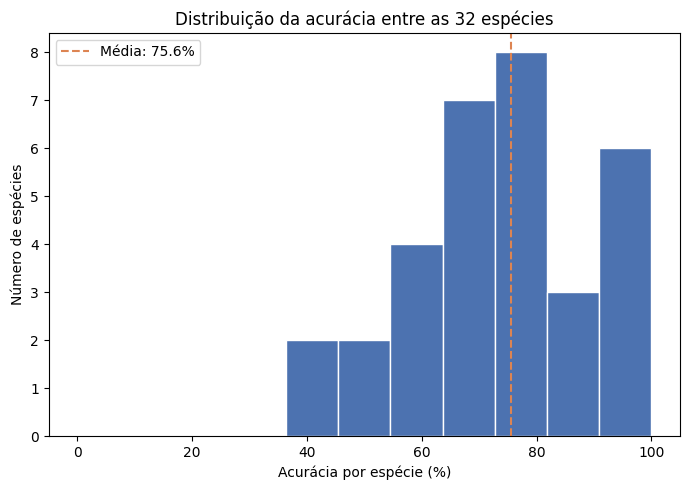

In [15]:
acuracias_por_especie = []
for label in species_list:
    mask = y_test == label
    total = mask.sum()
    acertos = np.sum(y_pred[mask] == label)
    acuracias_por_especie.append(acertos / total * 100)

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(
    acuracias_por_especie, bins=11, range=(0, 100), color="#4C72B0", edgecolor="white"
)
ax.axvline(
    np.mean(acuracias_por_especie),
    color="#DD8452",
    linestyle="--",
    label=f"Média: {np.mean(acuracias_por_especie):.1f}%",
)
ax.set_xlabel("Acurácia por espécie (%)")
ax.set_ylabel("Número de espécies")
ax.set_title("Distribuição da acurácia entre as 32 espécies")
ax.legend()
plt.tight_layout()
plt.show()

# Conclusão

Finalmente, implementou-se, neste trabalho, um classificador de folhas de plantas utilizando uma Probabilistic Neural Network (PNN), conforme a metodologia descrita no artigo de referência. Foram implementadas as etapas de extração das características, redução de dimensionalidade por PCA, construção da rede e classificação das amostras de teste.

Os experimentos demonstraram que a implementação foi capaz de identificar corretamente a maior parte das espécies de plantas, obtendo uma acurácia de aproximadamente 75,6%. Embora esse resultado seja inferior aos cerca de 90% apresentados no artigo original, a diferença pode ser atribuída a fatores como pequenas diferenças na implementação, na extração das características, na seleção das amostras de treinamento e teste e em detalhes do pré-processamento das imagens.

De forma geral, a arquitetura da PNN é eficiente para o problema de reconhecimento de folhas, além de possuir implementação relativamente simples e baixo custo computacional para a etapa de classificação.